In [21]:
import pandas as pd

# Upload files

df = pd.read_csv('ab_test_data.csv', encoding='utf-8')

# Check result
print(f"upload lines: {len(df)}")
df.head()

upload lines: 19998


,user_id,timestamp,test_group,conversion
0,7f6833e6-1141-4f20-b4b2-f1e31019b1fd,2023-07-04 04:40:55.848109,a,0
1,e6a6e960-d3f3-4074-a516-ba1e609b211e,2023-07-06 00:26:45.486187,b,0
2,4d3fbfa5-6847-410a-bac2-477f01d5f400,2023-07-10 20:24:33.639464,b,0
3,361457d9-a044-48f7-981c-d67dc3861679,2023-07-20 07:04:49.957013,b,0
4,285cd63d-7d03-427f-a062-1fa2dd2e77d6,2023-07-19 23:27:50.116680,b,0


In [22]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [23]:
# Сортуємо за часом (за замовчуванням — від найменшого до найбільшого)
df = df.sort_values(by='timestamp')

# Якщо хочеш скинути індекси після сортування, щоб вони йшли по порядку (0, 1, 2...):
df = df.reset_index(drop=True)

In [24]:
start_date = df['timestamp'].min()
end_date = df['timestamp'].max()
duration = (end_date - start_date).days

print(f"Початок тесту: {start_date}")
print(f"Кінець тесту: {end_date}")
print(f"Тривалість: {duration} днів")

Початок тесту: 2023-07-03 01:42:34.033708
Кінець тесту: 2023-07-25 01:41:19.152664
Тривалість: 21 днів


In [25]:
# Count unique values ResponseID
total_respondents_unique = df['user_id'].nunique()

# Output results
total_respondents_unique

19998

In [26]:
df.groupby('test_group').describe()

timestamp                                 \
               count                           mean   
test_group                                            
a              10013  2023-07-14 02:34:29.519821056   
b               9985  2023-07-13 21:37:07.888925696   

                                                                       \
                                   min                            25%   
test_group                                                              
a           2023-07-03 01:46:14.688840  2023-07-08 13:48:52.874817024   
b           2023-07-03 01:42:34.033708  2023-07-08 08:08:48.495631104   

                                                                          \
                                      50%                            75%   
test_group                                                                 
a           2023-07-14 03:49:36.002731008  2023-07-19 14:06:28.688054016   
b           2023-07-13 19:14:14.073116928  2023-07-19 09:59:58.771382016   

                                            conversion                      \
                                   max  std      count      mean  min  25%   
test_group                                                                   
a           2023-07-25 01:41:19.152664  NaN    10013.0  0.061021  0.0  0.0   
b           2023-07-25 01:35:59.130658  NaN     9985.0  0.089034  0.0  0.0   

                                     
            50%  75%  max       std  
test_group                           
a           0.0  0.0  1.0  0.239380  
b           0.0  0.0  1.0  0.284806

T-test

In [27]:
from scipy import stats

alpha = 0.05

statistic, pvalue = stats.ttest_ind(df[df['test_group'] == 'a']['conversion'],
                                    df[df['test_group'] == 'b']['conversion'], 
                                    alternative='less')

print(f't-statistic: {round(statistic, 2)}, p-value: {round(pvalue, 2)}')

if pvalue < alpha:
    print('The difference is statistically significant, Null Hypothesis is rejected.')
else:
    print('The difference is insignificant, Null Hypothesis cannot rejected.')

t-statistic: -7.53, p-value: 0.0
The difference is statistically significant, Null Hypothesis is rejected.


In [28]:
from scipy import stats

alpha = 0.05

observed = pd.crosstab(df['test_group'].values, df['conversion'].values)
statistic, pvalue, dof, expected_values = stats.chi2_contingency(observed)

print(f'chi2_contingency: {round(statistic, 2)}, p-value: {round(pvalue, 2)}')

if pvalue < alpha:
    print('The difference is statistically significant, Null Hypothesis is rejected.')
else:
    print('The difference is insignificant, Null Hypothesis cannot rejected.')

chi2_contingency: 56.14, p-value: 0.0
The difference is statistically significant, Null Hypothesis is rejected.


In [29]:
from scipy import stats

def statistic(x, y):
    return stats.ttest_ind(x, y).statistic

alpha = 0.05
    
x = df[df['test_group'] == 'a']['conversion']
y = df[df['test_group'] == 'b']['conversion']

results = stats.permutation_test((x, y), statistic, n_resamples=100)

print(f'statistic: {round(results.statistic, 2)}, p-value: {round(results.pvalue, 2)}')

if results.pvalue < alpha:
    print('The difference is statistically significant, Null Hypothesis is rejected.')
else:
    print('The difference is insignificant, Null Hypothesis cannot rejected.')

statistic: -7.53, p-value: 0.02
The difference is statistically significant, Null Hypothesis is rejected.


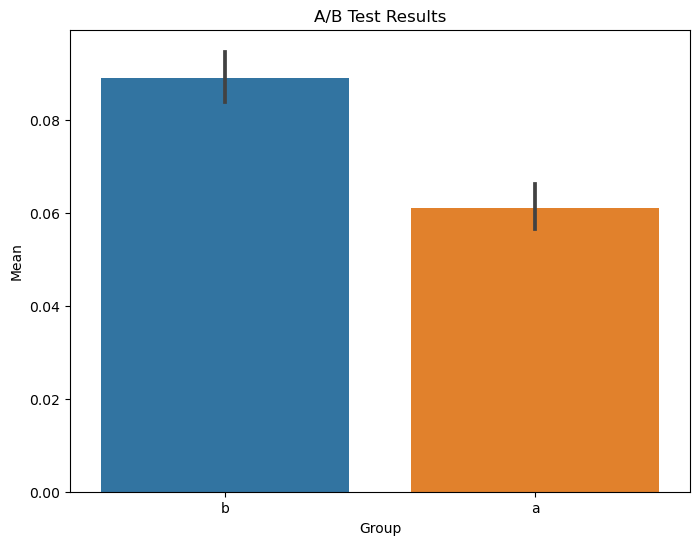

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.barplot(x=df['test_group'], 
            y=df['conversion'], 
            errorbar=('ci', 95)) # Confidence Intervals

plt.title('A/B Test Results')
plt.xlabel('Group')
plt.ylabel('Mean')

plt.show()

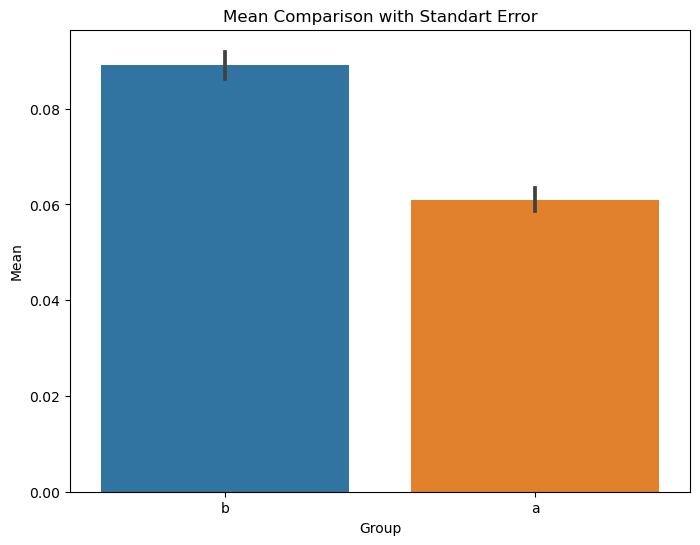

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.barplot(x=df['test_group'], 
            y=df['conversion'], 
            errorbar=('se'))

plt.title('Mean Comparison with Standart Error')
plt.xlabel('Group')
plt.ylabel('Mean')

plt.show()

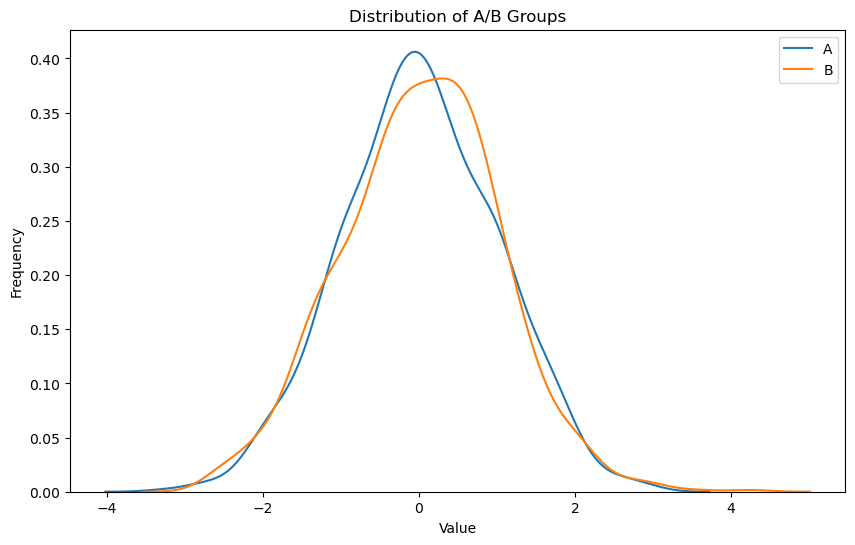

In [32]:
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.kdeplot(stats.norm.rvs(size=1000))
sns.kdeplot(stats.norm.rvs(size=1000))

plt.title('Distribution of A/B Groups')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.legend(['A', 'B'])
plt.show()

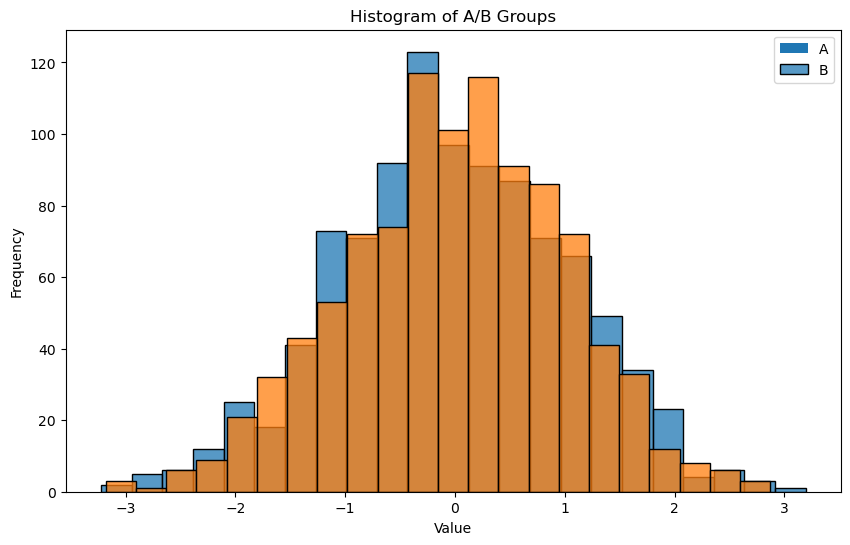

In [33]:
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.histplot(stats.norm.rvs(size=1000))
sns.histplot(stats.norm.rvs(size=1000))

plt.title('Histogram of A/B Groups')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.legend(['A', 'B'])
plt.show()

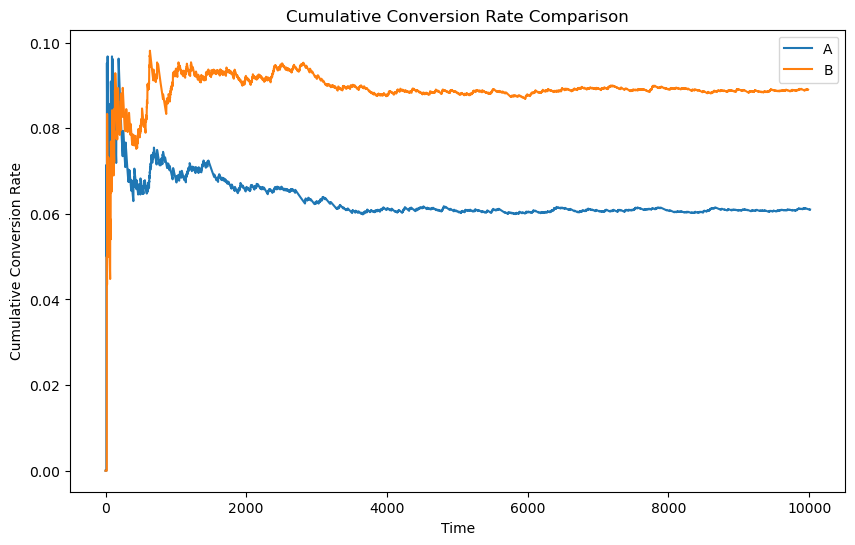

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Перемішуємо дані, оскільки зараз вони упорядковані за значенням конверсії
# Якби ми використовували реальні дані - тут мало б бути сортування за датою та часом
df = df.sample(frac=1).reset_index(drop=True)

# Рахуємо кумулятивне середнє - це і є зміна конверсії з плином часу
cumulative_metric_a = df[df['test_group'] == 'a']['conversion'].expanding().mean().reset_index(drop=True)
cumulative_metric_b = df[df['test_group'] == 'b']['conversion'].expanding().mean().reset_index(drop=True)

plt.figure(figsize=(10, 6))
plt.plot(cumulative_metric_a, label='A')
plt.plot(cumulative_metric_b, label='B')

plt.title('Cumulative Сonversion Rate Comparison')
plt.xlabel('Time')
plt.ylabel('Cumulative Сonversion Rate')

plt.legend()
plt.show()